In [112]:
# Импортируем все полезное нам
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
# Загрузка данных
df = pd.read_csv("../data/raw/london_merged.csv")

In [114]:
# Настройки визуализации
sns.set_theme(rc={"figure.figsize": (12, 6)}, palette="muted")
current_palette = sns.color_palette()
plt.style.use("ggplot")

Информация с https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset, на ее основе можно интерпретировать последующие графики:

**Metadata**:

- "timestamp" - timestamp field for grouping the data
- "cnt" - the count of a new bike shares
- "t1" - real temperature in C
- "t2" - temperature in C "feels like"
- "hum" - humidity in percentage
- "wind_speed" - wind speed in km/h
- "weather_code" - category of the weather
- "is_holiday" - boolean field - 1 holiday / 0 non holiday
- "is_weekend" - boolean field - 1 if the day is weekend
- "season" - category field meteorological seasons: 0-spring; 1-summer; 2-fall; 3-winter.

"weather_code" category description:
- 1 = Clear ; mostly clear but have some values with haze/fog/patches of fog/ fog in vicinity
- 2 = scattered clouds / few clouds
- 3 = Broken clouds
- 4 = Cloudy
- 7 = Rain/ light Rain shower/ Light rain
- 10 = rain with thunderstorm
- 26 = snowfall
- 94 = Freezing Fog

In [115]:
# Базовая информация
print(f"Размер датасета: {df.shape}\n")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.info()

Размер датасета: (17414, 10)

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     17414 non-null  datetime64[us]
 1   cnt           17414 non-null  int64         
 2   t1            17414 non-null  float64       
 3   t2            17414 non-null  float64       
 4   hum           17414 non-null  float64       
 5   wind_speed    17414 non-null  float64       
 6   weather_code  17414 non-null  float64       
 7   is_holiday    17414 non-null  float64       
 8   is_weekend    17414 non-null  float64       
 9   season        17414 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 1.3 MB


Как можно видеть, из 17414 строк датасета, 17414 из них в каждом столбце являются non-null -> пропусков нет.

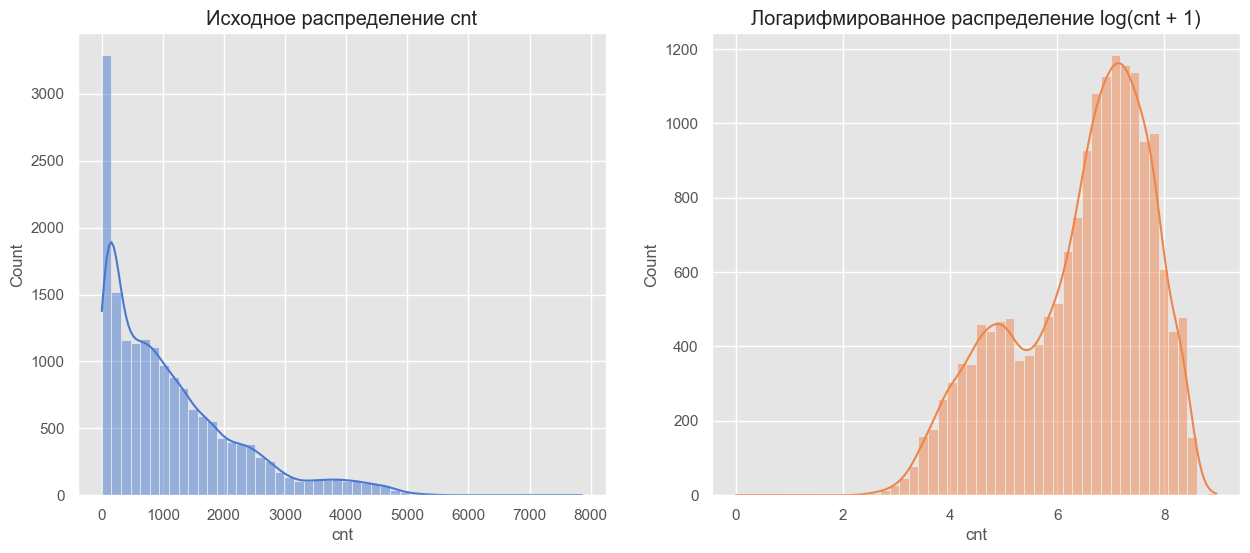

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df["cnt"], bins=50, kde=True, ax=axes[0], color=current_palette[0])
axes[0].set_title("Исходное распределение cnt")

sns.histplot(
    np.log1p(df["cnt"]), bins=50, kde=True, ax=axes[1], color=current_palette[1]
)
axes[1].set_title("Логарифмированное распределение log(cnt + 1)")

plt.show()

На исходном распределении cnt виден большой пик в нуле и длинный хвост в высоких значениях. Логарифмическое распределение помогает сгладить эти крайности и сделать распределение более нормальным.

Text(0.5, 1.0, 'Корреляция признаков')

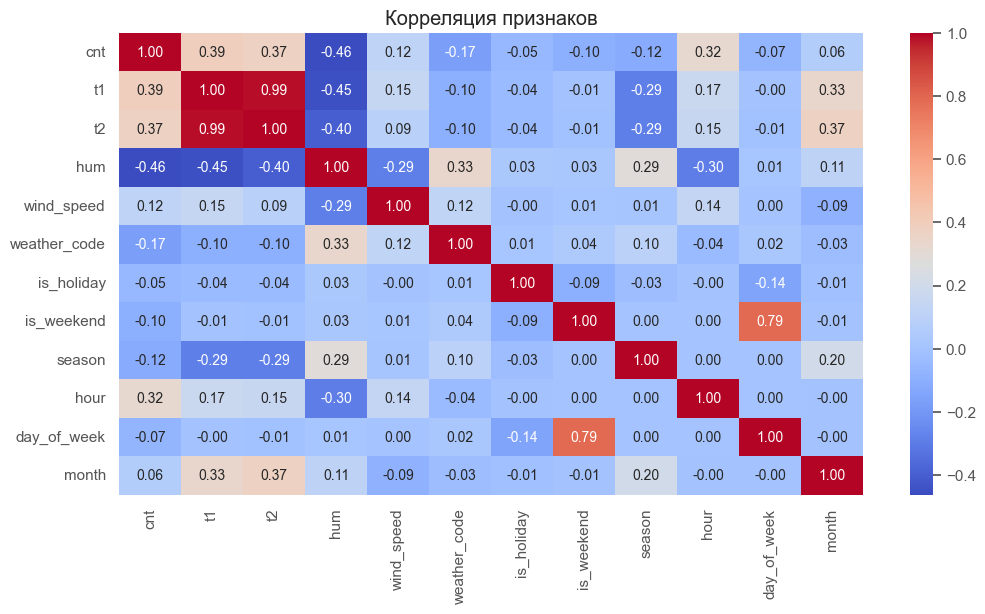

In [117]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

df = df.drop(["timestamp"], axis=1)

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция признаков")

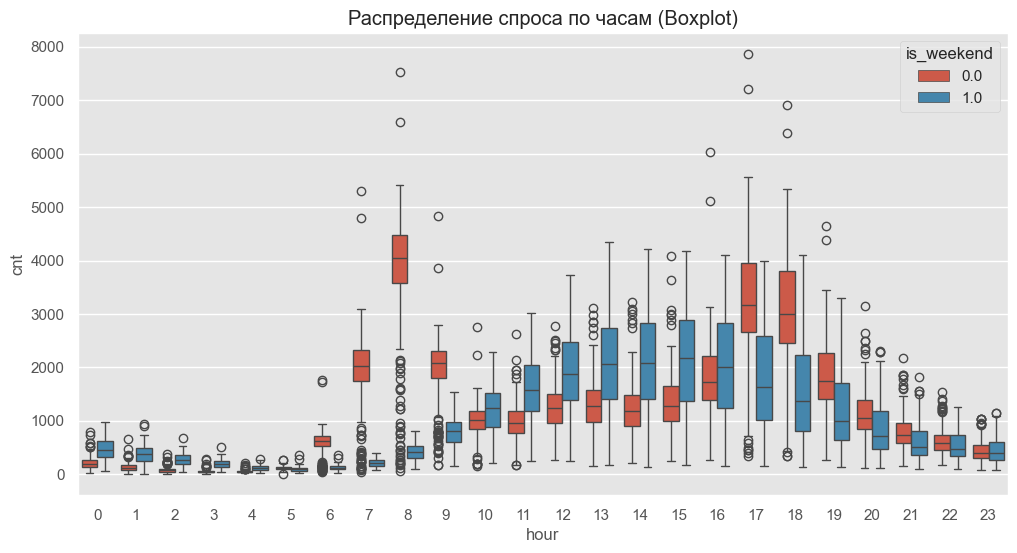

In [118]:
sns.boxplot(data=df, x="hour", y="cnt", hue="is_weekend")
plt.title("Распределение спроса по часам (Boxplot)")
plt.show()

Полученный график показывает ожидаемые результаты по этим данным. В будние дни (красные линии) наблюдается утренний (8 часов) и вечерний час пик (17-18 часов), где количество аренды велосипедов в пике. Наоборот, в выходные дни (синие линии) распределение количества аренды более равномерное, и его пик находится в обеденное время (14-15 часов).

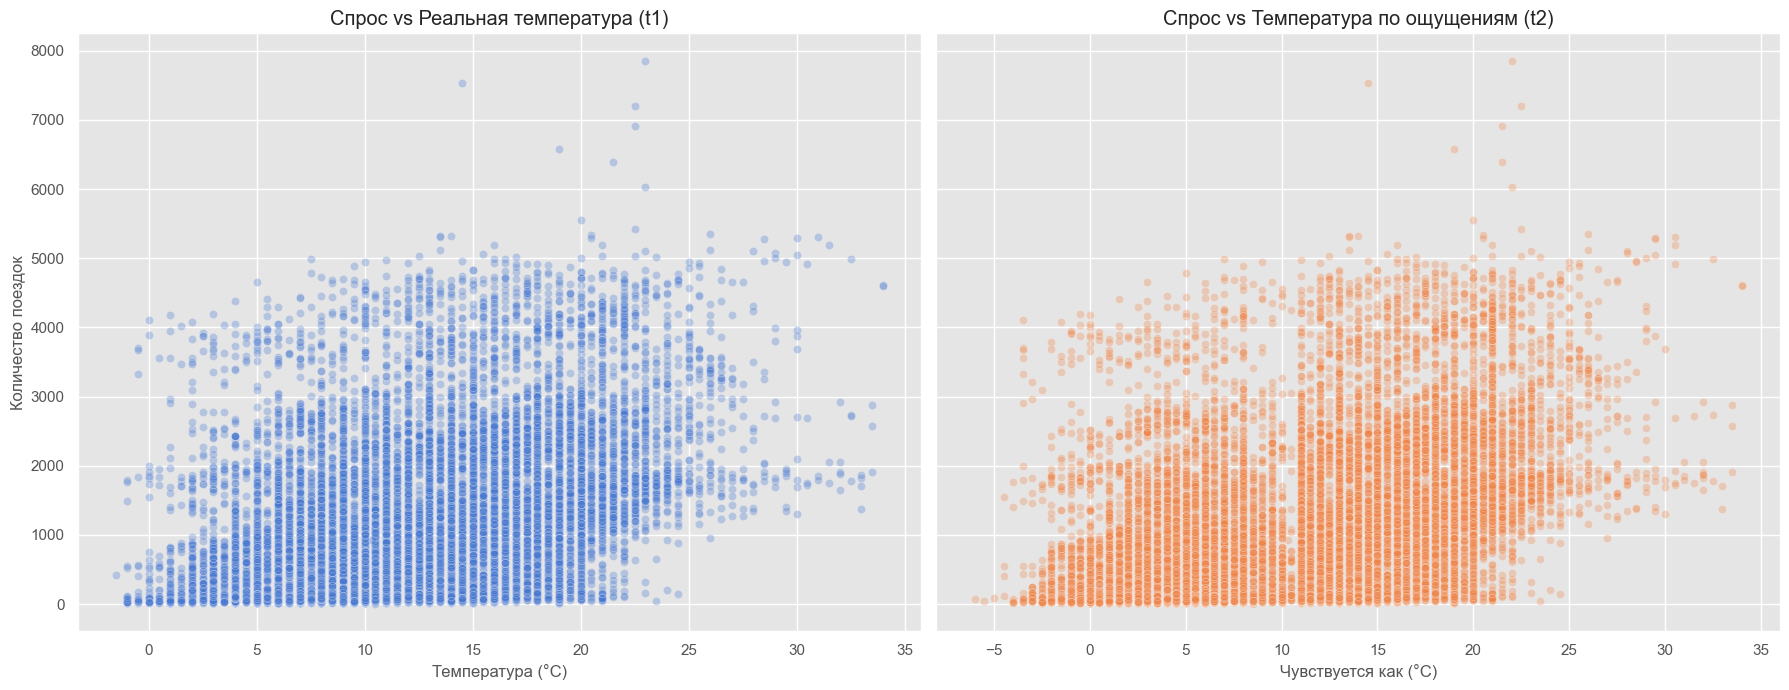

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.scatterplot(
    data=df, x="t1", y="cnt", alpha=0.3, ax=axes[0], color=current_palette[0]
)
axes[0].set_title("Спрос vs Реальная температура (t1)")
axes[0].set_xlabel("Температура (°C)")
axes[0].set_ylabel("Количество поездок")

sns.scatterplot(
    data=df, x="t2", y="cnt", alpha=0.3, ax=axes[1], color=current_palette[1]
)
axes[1].set_title("Спрос vs Температура по ощущениям (t2)")
axes[1].set_xlabel("Чувствуется как (°C)")

plt.tight_layout()
plt.show()

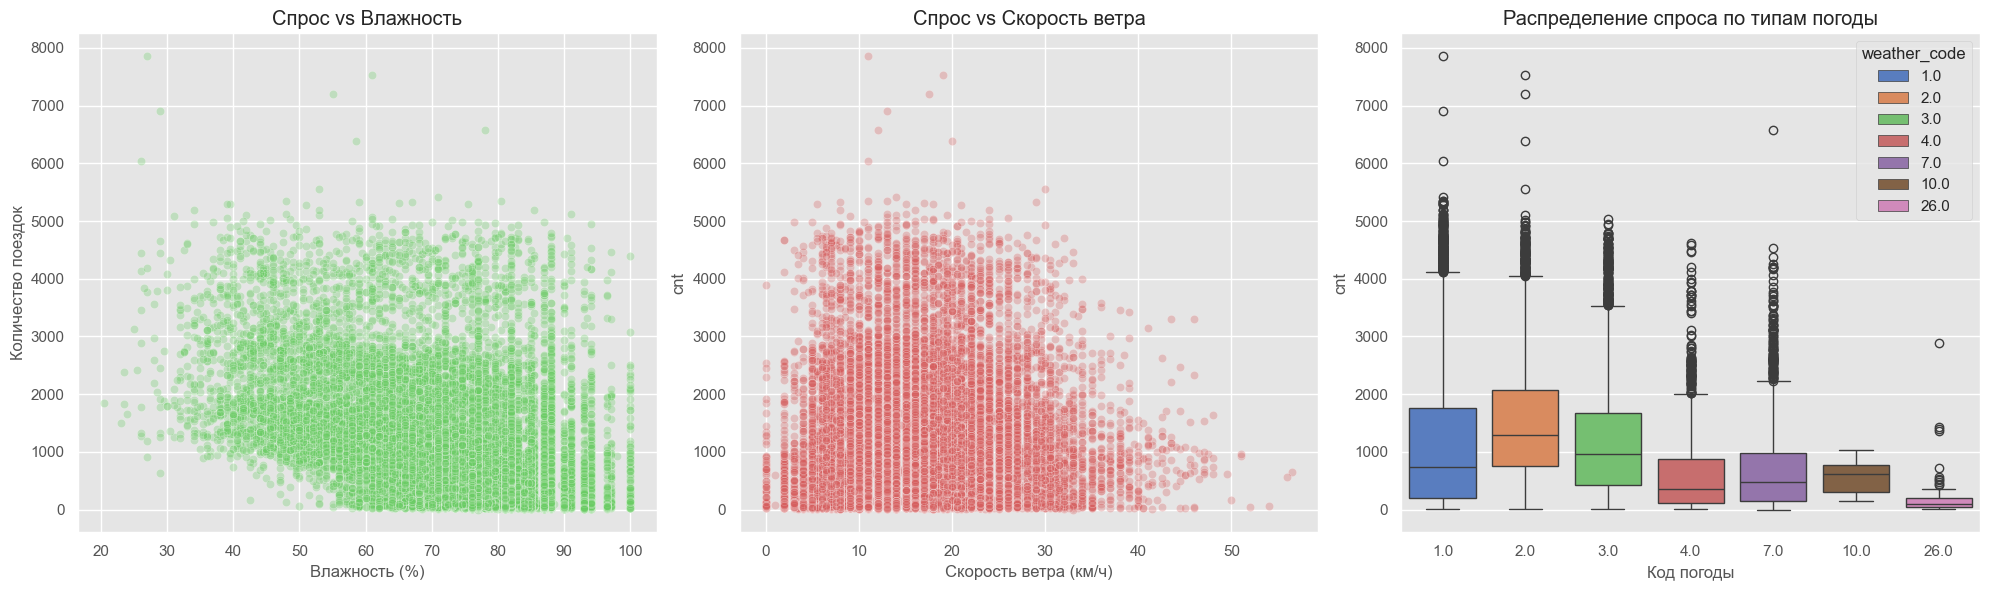

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. График по влажности
sns.scatterplot(
    data=df, x="hum", y="cnt", alpha=0.3, ax=axes[0], color=current_palette[2]
)
axes[0].set_title("Спрос vs Влажность")
axes[0].set_xlabel("Влажность (%)")
axes[0].set_ylabel("Количество поездок")

# 2. График по скорости ветра
sns.scatterplot(
    data=df, x="wind_speed", y="cnt", alpha=0.3, ax=axes[1], color=current_palette[3]
)
axes[1].set_title("Спрос vs Скорость ветра")
axes[1].set_xlabel("Скорость ветра (км/ч)")

# 3. График по погоде
sns.boxplot(
    data=df,
    x="weather_code",
    y="cnt",
    ax=axes[2],
    palette=current_palette[:7],
    hue="weather_code",
)
axes[2].set_title("Распределение спроса по типам погоды")
axes[2].set_xlabel("Код погоды")

plt.tight_layout()
plt.show()